In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 2450000
from emcee.autocorr import integrated_time

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5


mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [16]:
muN_correct_02  = 3.000000   # mas/yr
muE_correct_02   = 3.000000  # mas/yr
ML_correct_02      = 0.523487       # M_sun
DL_correct_02        =3.663743       # kpc
DS_correct_02       = 8.142611       # kpc
R_orbit_correct_02   = 2.999999 # AU
e_correct_02    = 0.500000
cos_i_correct_02    = 0.620905
Omega_correct_02    = (0.572726- np.pi)% (2*np.pi)
omega_correct_02    = -1.177002
nu_correct_02    =  -1.964761

t0_correct_02 = 10085 
u0_correct_02 = 0.01 
q_correct_02 = 0.005
alpha_correct_02 = 3.65*np.pi/4
tE_correct_02 = 68.5053
rho_correct_02 = 8.96025e-05
s_correct_02 = 0.950001
piEN_correct_02 = 0.128858
piEE_correct_02 = 0.136441
gamma1_correct_02 = -0.00137559
gamma2_correct_02 = 0.00149516
gamma3_correct_02 = -0.00188781
rs_correct_02 = 0.000133878
as_correct_02 = 1.07743

truths_lc_02 = [t0_correct_02,tE_correct_02,u0_correct_02,q_correct_02,s_correct_02,alpha_correct_02,rho_correct_02,piEN_correct_02,
               piEE_correct_02,gamma1_correct_02,gamma2_correct_02,gamma3_correct_02,rs_correct_02,as_correct_02]

truths_kep_02 = [
    ML_correct_02,
    DL_correct_02,
    DS_correct_02,
    muN_correct_02,
    muE_correct_02,
    R_orbit_correct_02,
    e_correct_02,
    cos_i_correct_02,
    omega_correct_02,
    Omega_correct_02,
    nu_correct_02
]

In [1]:
label_inds_kep = {
    "t0": 0,
    "tE": 1,
    "u0": 2,
    "rho": 3,
    "q": 4,
    "s": 5,
    "alpha": 6,
    "piEN": 7,
    "piEE": 8,
    "gamma1": 9,
    "gamma2": 10,
    "gamma3": 11,
    "rs": 12,
    "as": 13,
}
label_inds_kep_phys = {
    "ML":3,
    "DL": 4,
    "DS": 5,
    "muN": 6,
    "muE": 7,
    "a": 8,
    "e": 9,
    "cos_i": 10,
    "Omega": 11,
    "omega":12,
    "nu":13,
}

In [4]:
def read_chain(path,burnin,thin,flat=True):
    sampler = emcee.backends.HDFBackend(path)
    chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
    blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin) 
    lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin) 
    return chain, blob,lnprob

In [6]:
kep_wo_chain_03,kep_wo_blob_03,kep_wo_prob_03 = read_chain("../test_result/rogue1/backend/rerun_wo_gap_simu_03_kepler_chain_01.h5",0,1,flat=False)
kep_gap_chain_03,kep_gap_blob_03,kep_gap_prob_03 = read_chain("../test_result/rogue1/backend/rerun_simu_03_kepler_chain_01.h5",0,1,flat=False)


use_ind_gap_03 = np.where((kep_gap_chain_03[-1,:,0] < 10085.0025)&((np.abs(kep_gap_chain_03[-1,:,-2]) < 2.5)))[0]
use_ind_wo_03 = np.where((np.abs(kep_wo_chain_03[-1,:,1]) > 73))[0]

kep_wo_chain_03,kep_wo_blob_03,kep_wo_prob_03 = kep_wo_chain_03[:,use_ind_wo_03,:],kep_wo_blob_03[:,use_ind_wo_03],kep_wo_prob_03[:,use_ind_wo_03]
kep_gap_chain_03,kep_gap_blob_03,kep_gap_prob_03 = kep_gap_chain_03[:,use_ind_gap_03,:],kep_gap_blob_03[:,use_ind_gap_03],kep_gap_prob_03[:,use_ind_gap_03]


kep_wo_chain_03  = kep_wo_chain_03[100000:].reshape(-1, 14)[::1000+1]
kep_wo_blob_03 = kep_wo_blob_03[100000:].reshape(-1)[::1000+1]
kep_wo_prob_03 = kep_wo_prob_03[100000:].reshape(-1)[::1000+1]

kep_gap_chain_03 = kep_gap_chain_03[100000:].reshape(-1, 14)[::1000+1]
kep_gap_blob_03 = kep_gap_blob_03[100000:].reshape(-1)[::1000+1]
kep_gap_prob_03 = kep_gap_prob_03[100000:].reshape(-1)[::1000+1]

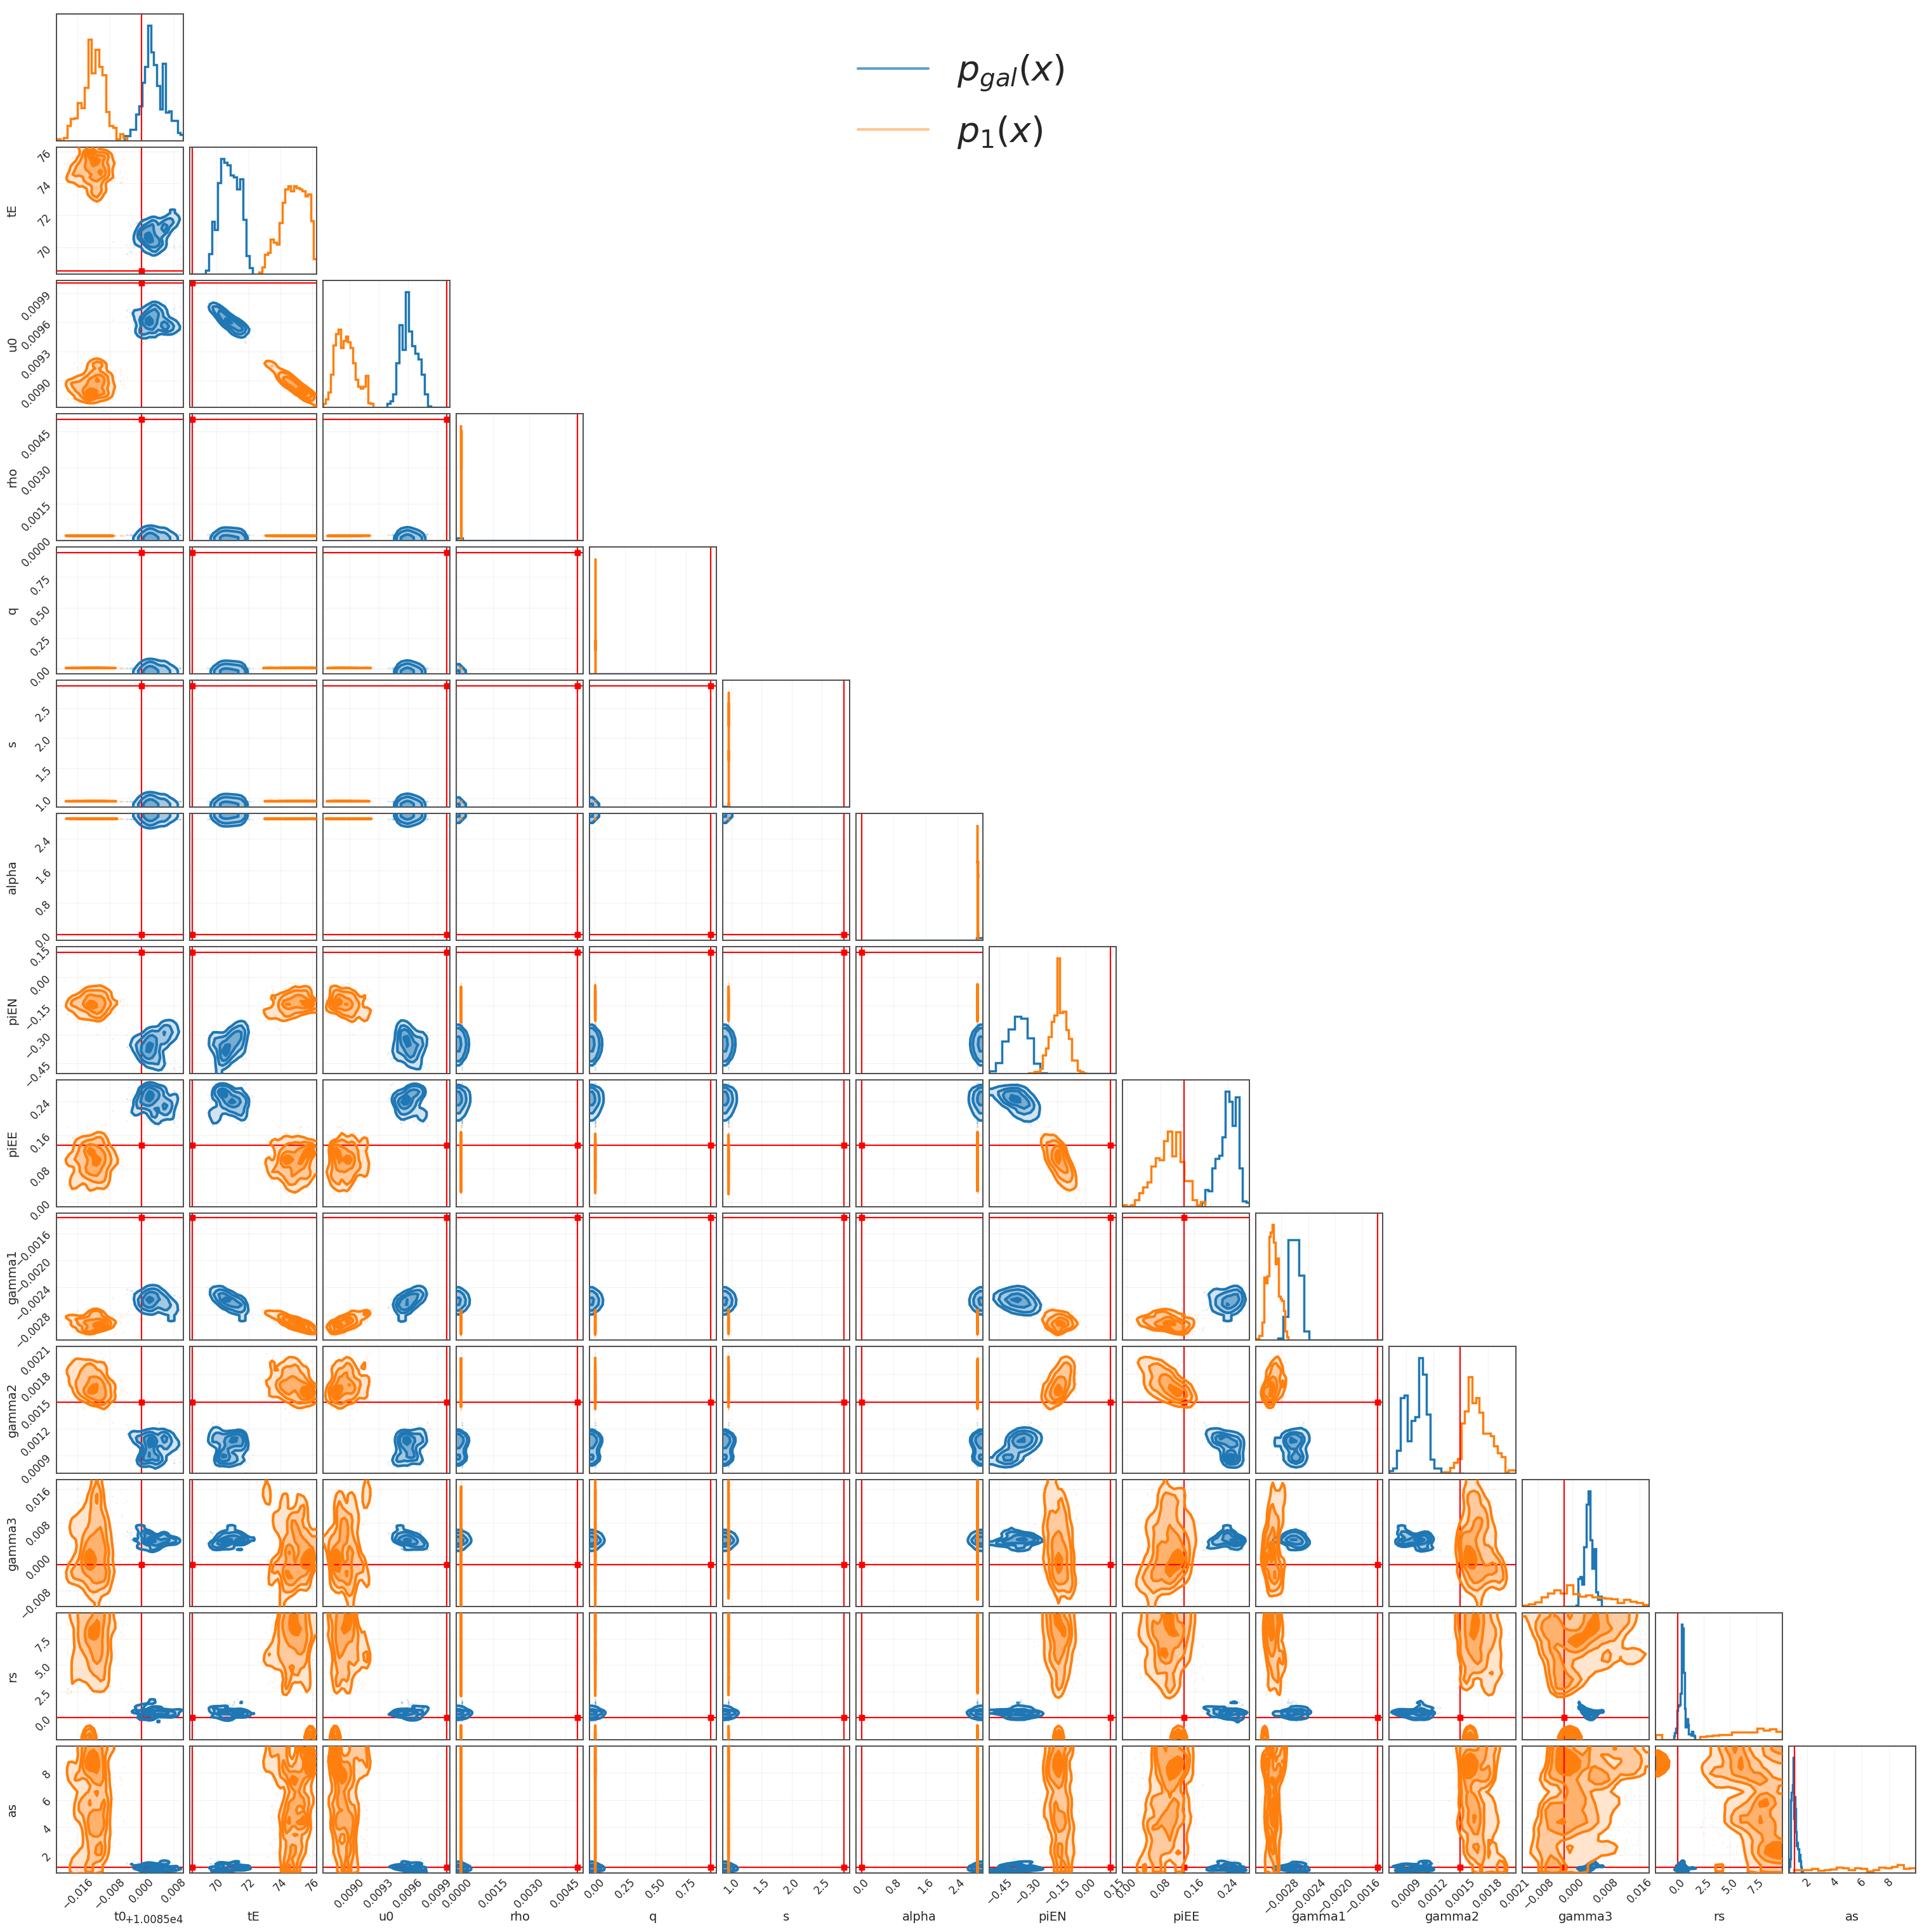

In [44]:
samples = np.asarray(kep_gap_chain_03)        # (nsamples, ndim)
truths  = np.asarray(truths_lc_02)            # (ndim,)

p_lo, p_hi = 0.5, 99.5                      
prc = np.percentile(samples, [p_lo, p_hi], axis=0) 

ranges = []
for i in range(samples.shape[1]):
    lo, hi = prc[0, i], prc[1, i]
    tr = truths[i]
    if np.isfinite(tr):
        lo = min(lo, tr)
        hi = max(hi, tr)
    pad = 0.05 * (hi - lo) if np.isfinite(hi - lo) and (hi > lo) else 1.0
    ranges.append((lo - pad, hi + pad))

fig = corner.corner(
    samples,
    labels=list(label_inds_kep.keys()),
    range=ranges,                     # ← これがポイント
    smooth=1,
    truths=truths,
    truth_color="red",
    truth_kwargs={"linewidth": 2.5, "zorder": 10},
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    fill_contours=True,
    show_titles=False,
    plot_density=True,
    plot_datapoints=True,
)

corner.corner(
    kep_wo_chain_03,
    fig=fig,
    smooth=1,
    truths=truths,
    truth_color="red",
    truth_kwargs={"linewidth": 2.5, "zorder": 10},
    color="C1",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    fill_contours=True,
    show_titles=False,
    plot_density=True,
    plot_datapoints=True,
)

legend_handles = [
    Line2D([0], [0], color="C0", lw=3, alpha=0.7, label=r"$p_{gal}(x)$"),
    Line2D([0], [0], color="C1", lw=3, alpha=0.45, label=r"$p_{1}(x)$")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    fontsize=40,
    frameon=False,
    borderpad=1,
    labelspacing=0.6
)


plt.savefig("/moao38_7/nunota/gapmoe/test_figures/event03_corner_lc.png")
plt.show()

In [25]:
vmap_kep = jax.vmap(
    lambda theta, thS: parametrics.lightcurve_to_physical_kepler(theta, thS, vEarth),
    in_axes=(0, 0)
)

kep_wo_phys_03 = vmap_kep(kep_wo_chain_03,kep_wo_blob_03  )
kep_gap_phys_03 = vmap_kep(kep_gap_chain_03,kep_gap_blob_03  )

In [ ]:
samples = np.asarray(kep_gap_phys_03[:,3:])        # (nsamples, ndim)
truths  = np.asarray(truths_kep_02)            # (ndim,)

p_lo, p_hi = 0.5, 99.5                      
prc = np.percentile(samples, [p_lo, p_hi], axis=0) 

ranges = []
for i in range(samples.shape[1]):
    lo, hi = prc[0, i], prc[1, i]
    tr = truths[i]
    if np.isfinite(tr):
        lo = min(lo, tr)
        hi = max(hi, tr)
    pad = 0.05 * (hi - lo) if np.isfinite(hi - lo) and (hi > lo) else 1.0
    ranges.append((lo - pad, hi + pad))

fig = corner.corner(
    samples,
    labels=list(label_inds_kep_phys.keys()),
    range=ranges,                  
    smooth=1,
    truths=truths,
    truth_color="red",
    truth_kwargs={"linewidth": 2.5, "zorder": 10},
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    fill_contours=True,
    show_titles=False,
    plot_density=True,
    plot_datapoints=True,
)


fig = corner.corner(
    np.asarray(kep_wo_phys_03[:,3:])    ,
    fig = fig,                  
    smooth=1,
    truths=truths,
    truth_color="red",
    truth_kwargs={"linewidth": 2.5, "zorder": 10},
    color="C1",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    fill_contours=True,
    show_titles=False,
    plot_density=True,
    plot_datapoints=True,
)

legend_handles = [
    Line2D([0], [0], color="C0", lw=3, alpha=0.7, label=r"$p_{gal}(x)$"),
    Line2D([0], [0], color="C1", lw=3, alpha=0.45, label=r"$p_{1}(x)$")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    fontsize=40,
    frameon=False,
    borderpad=1,
    labelspacing=0.6
)


plt.savefig("/moao38_7/nunota/gapmoe/test_figures/event03_corner_phys.png")

plt.show()

In [31]:
truths.shape

(11,)

In [32]:
samples.shape

(497, 9)